In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("/content/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (768, 9)


In [5]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [6]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
Outcome


Outcome
0    500
1    268
Name: count, dtype: int64


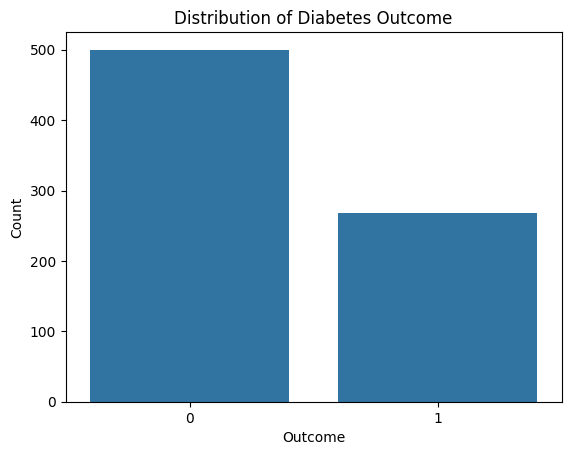

In [12]:
print(y.value_counts())

sns.countplot(x=y)
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

In [13]:
columns_with_possible_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in columns_with_possible_zero:
    print(f"{col}: {(df[col] == 0).sum()} zero values")

Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


In [14]:
df_processed = df.copy()

for col in columns_with_possible_zero:
    df_processed[col] = df_processed[col].replace(0, np.nan)

df_processed.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [15]:
imputer = SimpleImputer(strategy="median")

df_processed[columns_with_possible_zero] = imputer.fit_transform(
    df_processed[columns_with_possible_zero]
)

df_processed.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [16]:
X = df_processed.drop("Outcome", axis=1)
y = df_processed["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (614, 8)
Testing set: (154, 8)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_train_pred_lr = logistic_model.predict(X_train_scaled)
y_test_pred_lr = logistic_model.predict(X_test_scaled)

In [22]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

y_train_pred_tree = tree_model.predict(X_train)
y_test_pred_tree = tree_model.predict(X_test)

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

In [24]:
def evaluate_model(model_name, y_train, train_pred, y_test, test_pred):
    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print("Training Accuracy:",
          accuracy_score(y_train, train_pred))

    print("Testing Accuracy:",
          accuracy_score(y_test, test_pred))

    print("Precision:",
          precision_score(y_test, test_pred))

    print("Recall:",
          recall_score(y_test, test_pred))

    print("F1-Score:",
          f1_score(y_test, test_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, test_pred))

In [25]:
evaluate_model(
    "Logistic Regression",
    y_train,
    y_train_pred_lr,
    y_test,
    y_test_pred_lr
)

Logistic Regression
Training Accuracy: 0.7964169381107492
Testing Accuracy: 0.7077922077922078
Precision: 0.6
Recall: 0.5
F1-Score: 0.5454545454545454

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [26]:
evaluate_model(
    "Decision Tree",
    y_train,
    y_train_pred_tree,
    y_test,
    y_test_pred_tree
)

Decision Tree
Training Accuracy: 0.8143322475570033
Testing Accuracy: 0.7597402597402597
Precision: 0.639344262295082
Recall: 0.7222222222222222
F1-Score: 0.6782608695652174

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       100
           1       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



In [27]:
evaluate_model(
    "Random Forest",
    y_train,
    y_train_pred_rf,
    y_test,
    y_test_pred_rf
)

Random Forest
Training Accuracy: 1.0
Testing Accuracy: 0.7792207792207793
Precision: 0.7272727272727273
Recall: 0.5925925925925926
F1-Score: 0.6530612244897959

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



In [28]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_test_pred_lr),
        accuracy_score(y_test, y_test_pred_tree),
        accuracy_score(y_test, y_test_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_test_pred_lr),
        precision_score(y_test, y_test_pred_tree),
        precision_score(y_test, y_test_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_test_pred_lr),
        recall_score(y_test, y_test_pred_tree),
        recall_score(y_test, y_test_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_test_pred_lr),
        f1_score(y_test, y_test_pred_tree),
        f1_score(y_test, y_test_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455
1,Decision Tree,0.759740,0.639344,0.722222,0.678261
2,Random Forest,0.779221,0.727273,0.592593,0.653061


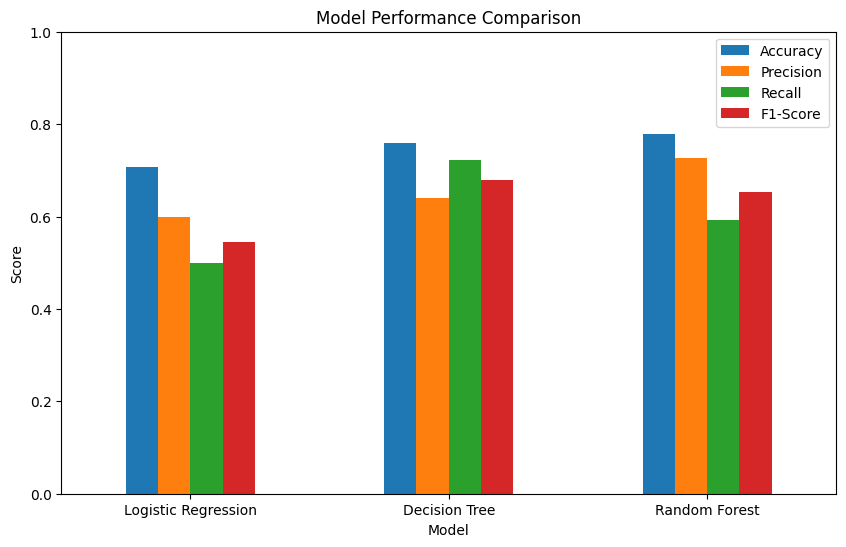

In [29]:
results.set_index("Model").plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

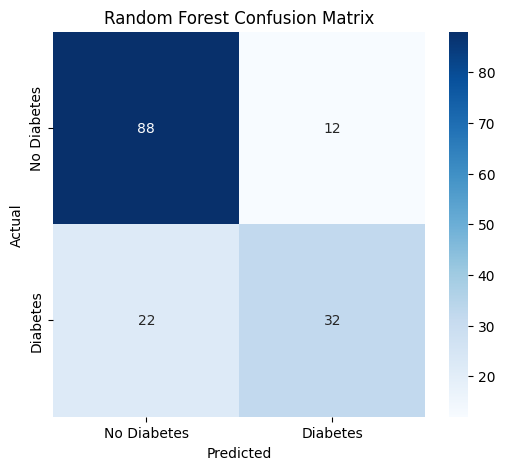

In [30]:
cm = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [31]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred_rf
).ravel()

print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)

True Negative (TN): 88
False Positive (FP): 12
False Negative (FN): 22
True Positive (TP): 32


In [32]:
training_accuracy = accuracy_score(y_train, y_train_pred_rf)
testing_accuracy = accuracy_score(y_test, y_test_pred_rf)

print("Training Accuracy:", training_accuracy)
print("Testing Accuracy:", testing_accuracy)
print("Difference:", training_accuracy - testing_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.7792207792207793
Difference: 0.22077922077922074


In [33]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Glucose,0.274086
5,BMI,0.161903
6,DiabetesPedigreeFunction,0.125020
7,Age,0.112985
4,Insulin,0.091224
2,BloodPressure,0.083518
0,Pregnancies,0.080795
3,SkinThickness,0.070468


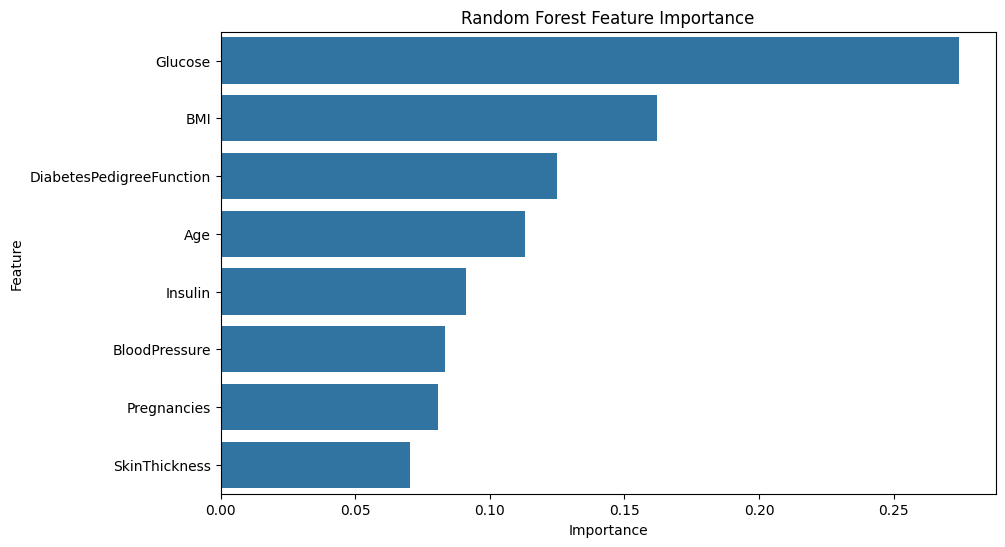

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()

In [35]:
best_model = results.loc[
    results["F1-Score"].idxmax()
]

print("Best Performing Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1-Score:", best_model["F1-Score"])

Best Performing Model: Decision Tree
Accuracy: 0.7597402597402597
Precision: 0.639344262295082
Recall: 0.7222222222222222
F1-Score: 0.6782608695652174
